<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          683 non-null    str    
 1   discoverymethod  683 non-null    str    
 2   pl_orbper        683 non-null    float64
 3   pl_orbpererr1    666 non-null    float64
 4   pl_orbpererr2    666 non-null    float64
 5   pl_orbperlim     683 non-null    int64  
 6   pl_orbsmax       667 non-null    float64
 7   pl_orbsmaxerr1   636 non-null    float64
 8   pl_orbsmaxerr2   636 non-null    float64
 9   pl_orbsmaxlim    667 non-null    float64
 10  pl_rade          683 non-null    float64
 11  pl_radeerr1      677 non-null    float64
 12  pl_radeerr2      677 non-null    float64
 13  pl_radelim       683 non-null    int64  
 14  pl_bmasse        664 non-null    float64
 15  pl_bmasseerr1    628 non-null    float64
 16  pl_bmasseerr2    628 non-null    float64
 17  pl_bmasselim     664 non-nu

    pl_rade  pl_eqt  pl_insol  pl_orbper  st_met  pl_bmasse
0  8.097382   739.3   49.5800   7.327947   0.099  39.855882
1  8.140000  1038.0  149.0000   9.127055   0.439  81.700000
3  8.200000  1038.0  373.1080   4.583522   0.050  51.100000
4  8.294646   690.0   39.0000   3.936551   0.400  82.635386
5  8.339482   555.4   17.0012   3.471683   0.357  79.774930


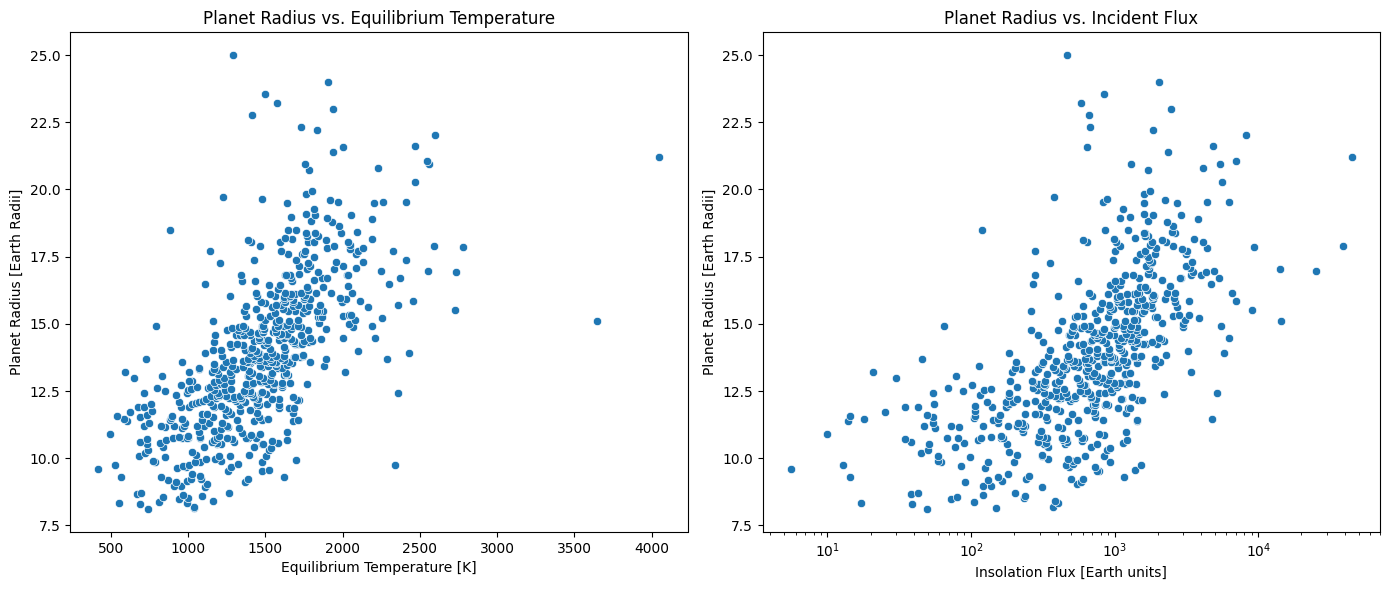

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reads Data from NASA Exoplanet Archive
df = pd.read_csv("./PSCompPars_2026.03.16_20.49.11.csv", comment='#')
df.columns = df.columns.str.strip()

# Clean Data
# Clean to keep Radius, Equilibrium Temperature, Flux, Orbital Period, Metallicity, Mass
df = df[['pl_rade', 'pl_eqt', 'pl_insol', 'pl_orbper', 'st_met', 'pl_bmasse']]
# Clean missing values in Data
hj = df.dropna(subset=['pl_rade', 'pl_eqt', 'pl_insol', 'pl_orbper', 'st_met', 'pl_bmasse'])
print(hj.head())

# Calculate Inflation
# Define Inflation Anomaly (Difference between observed and cold jupiter baseline of 1.1)
hj['inflation_anomaly'] = hj['pl_rade'] - 1.1
print(hj.inflation_anomaly)

# Create the multi-parameter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Temperature vs Radius Plot
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', ax=ax1)
ax1.set_title('Planet Radius vs. Equilibrium Temperature')
ax1.set_xlabel('Equilibrium Temperature [K]')
ax1.set_ylabel('Planet Radius [Earth Radii]')

# Flux vs Radius Plot
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', ax=ax2)
ax2.set_xscale('log')
ax2.set_title('Planet Radius vs. Incident Flux')
ax2.set_xlabel('Insolation Flux [Earth units]')
ax2.set_ylabel('Planet Radius [Earth Radii]')

plt.tight_layout()
plt.show()

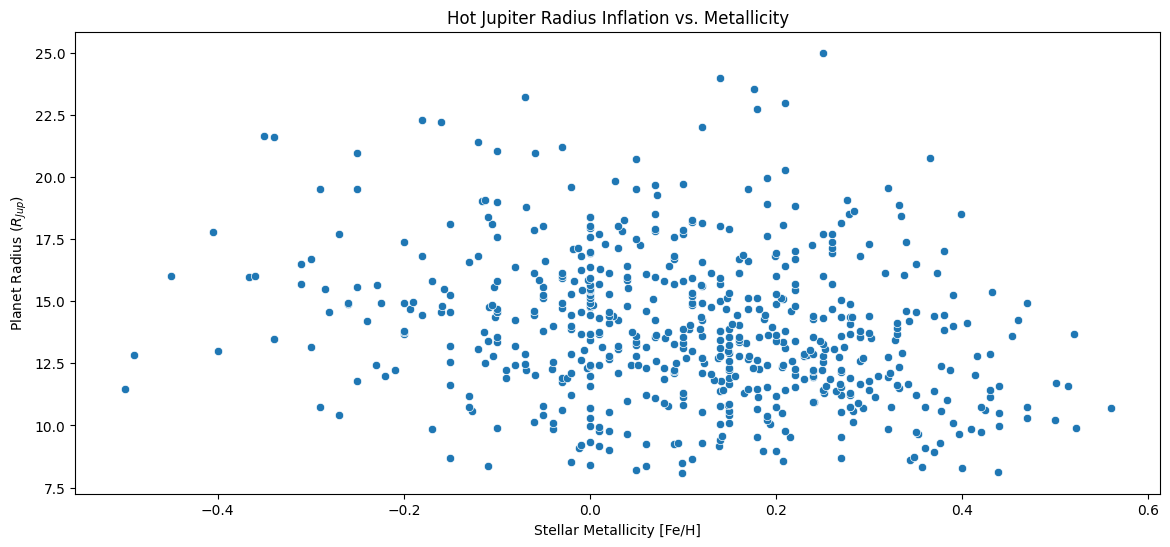

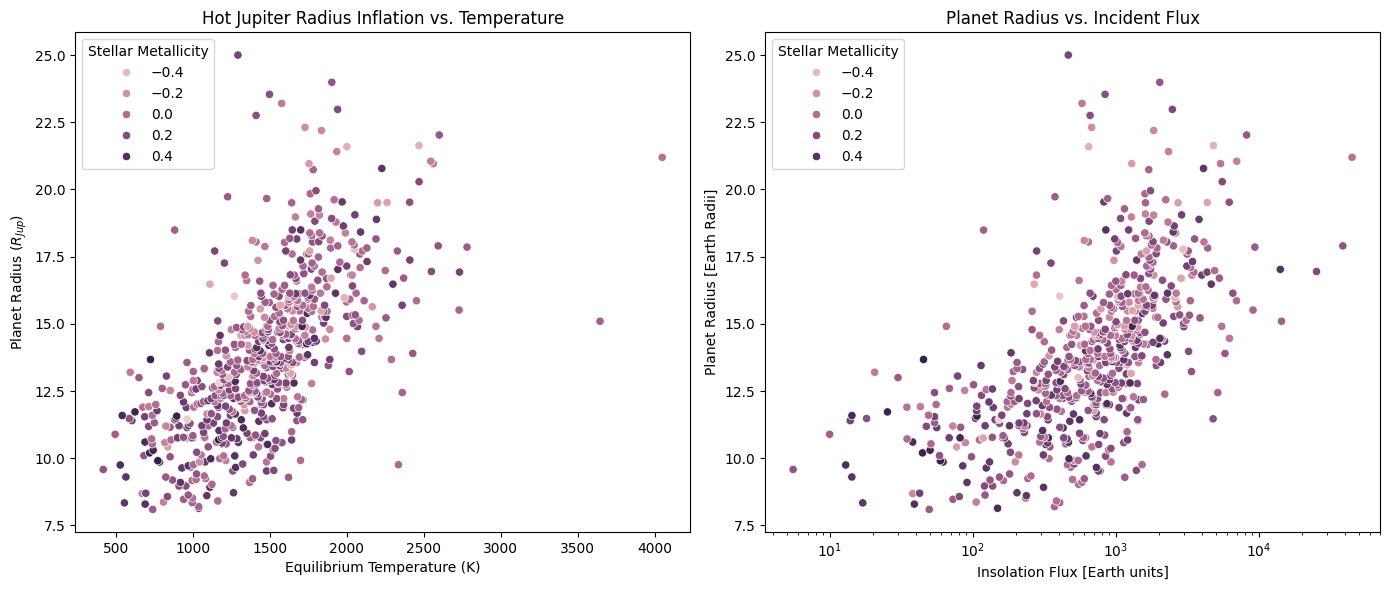

In [42]:
plt.figure(figsize=(14,6))
# Plot Inflation vs Metallicity
me = sns.scatterplot(data=hj, x='st_met', y='pl_rade')
me.set_xlabel('Stellar Metallicity [Fe/H]')
me.set_ylabel('Planet Radius ($R_{Jup}$)')
me.set_title('Hot Jupiter Radius Inflation vs. Metallicity')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))

# PLot Correlation between Metallicty relate to inflation
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', hue='st_met', ax=ax3)
ax3.set_xlabel('Equilibrium Temperature (K)')
ax3.set_ylabel('Planet Radius ($R_{Jup}$)')
ax3.set_title('Hot Jupiter Radius Inflation vs. Temperature')
ax3.legend_.set_title("Stellar Metallicity")

# Flux vs Radius Plot
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', hue='st_met', ax=ax4)
ax4.set_xscale('log')
ax4.set_title('Planet Radius vs. Incident Flux')
ax4.set_xlabel('Insolation Flux [Earth units]')
ax4.set_ylabel('Planet Radius [Earth Radii]')
ax4.legend_.set_title("Stellar Metallicity")


plt.tight_layout()
plt.show()




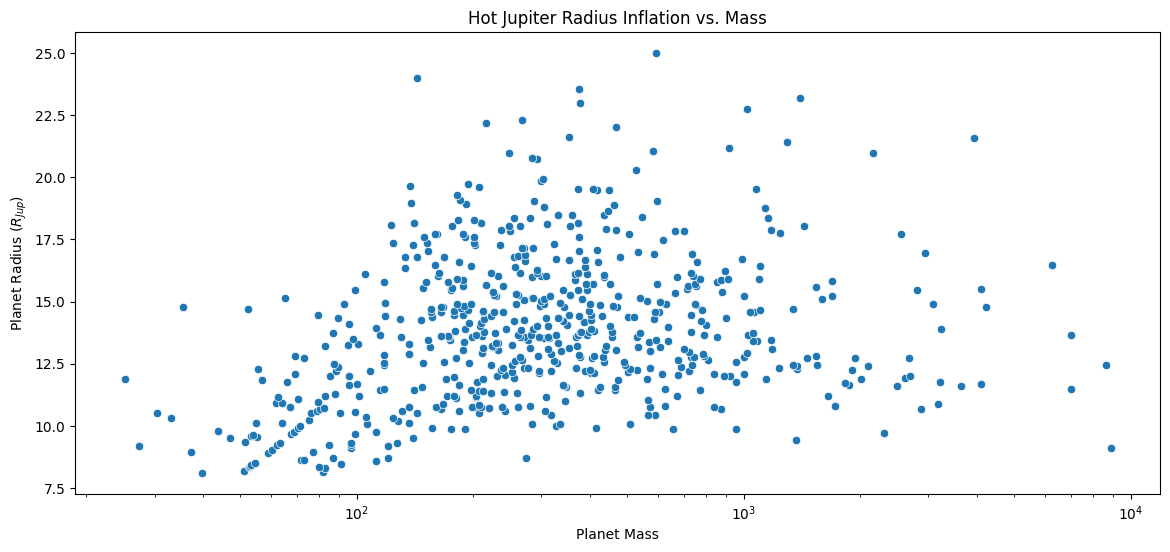

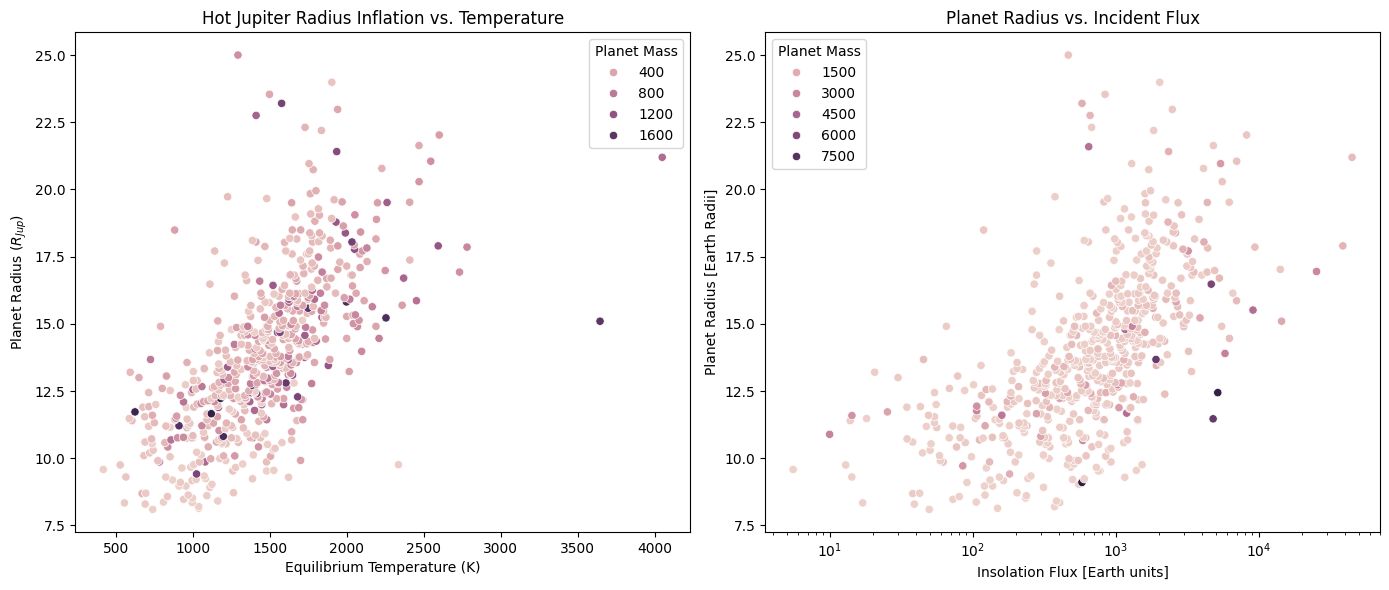

In [43]:
# Plot for correlation between Mass and Inflation

#ma=hj[hj['pl_bmasse']<2000]
plt.figure(figsize=(14,6))
mas = sns.scatterplot(data=hj, x='pl_bmasse', y='pl_rade')
mas.set_xscale('log')
mas.set_xlabel('Planet Mass')
mas.set_ylabel('Planet Radius ($R_{Jup}$)')
mas.set_title('Hot Jupiter Radius Inflation vs. Mass')


fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))

# PLot Correlation between Metallicty relate to inflation
sns.scatterplot(data=ma, x='pl_eqt', y='pl_rade', hue='pl_bmasse', ax=ax5)
ax5.set_xlabel('Equilibrium Temperature (K)')
ax5.set_ylabel('Planet Radius ($R_{Jup}$)')
ax5.set_title('Hot Jupiter Radius Inflation vs. Temperature')
ax5.legend_.set_title("Planet Mass")

# Flux vs Radius Plot
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', hue='pl_bmasse', ax=ax6)
ax6.set_xscale('log')
ax6.set_title('Planet Radius vs. Incident Flux')
ax6.set_xlabel('Insolation Flux [Earth units]')
ax6.set_ylabel('Planet Radius [Earth Radii]')
ax6.legend_.set_title("Planet Mass")

plt.tight_layout()
plt.show()